# Importing Libraries and Defining Features

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS


West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU
#ALL_COUNTRIES = West_EU

#FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC"]
FEATURES = ["gdp_growth_rate_Percent", "ln_hdd"]
FEATURES_ln = ["ln_pop", "ln_gdp_pc", "ln_hdd"]

TARGET = ["Total_Heat_TJ"]
TARGET_ln = ["ln_total_heat"]

# Data Preparation

## Preparing the data on share of technologies in Total Heat

In [116]:
nrg_d_hhq = pd.read_csv("Heat Pump/eurostat_nrg_d_hhq.csv")

# selecting only the wanted columns and renaming name
nrg_d_hhq = nrg_d_hhq[["nrg_bal", "Standard international energy product classification (SIEC)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
nrg_d_hhq= nrg_d_hhq.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "Energy_TJ",
    "Standard international energy product classification (SIEC)": "carrier"
})  

# sum of both space heating and water heating
nrg_d_hhq_heating = (
    nrg_d_hhq
    .groupby(["carrier", "country", "year"], as_index=False)["Energy_TJ"]
    .sum()
)

# Get the "Total" value for each country-year
totals = (
    nrg_d_hhq_heating[nrg_d_hhq_heating["carrier"] == "Total"]
    [["country", "year", "Energy_TJ"]]
    .rename(columns={"Energy_TJ": "Total_Energy_TJ"})
)

# Merge totals back to the main dataframe
nrg_d_hhq_heating = nrg_d_hhq_heating.merge(
    totals,
    on=["country", "year"],
    how="left"
)

# Compute share
nrg_d_hhq_heating["share_pu"] = (
    nrg_d_hhq_heating["Energy_TJ"] /
    nrg_d_hhq_heating["Total_Energy_TJ"]
)

#nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total") & (nrg_d_hhq_heating.country=="Norway")]
nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.country=="France") & (nrg_d_hhq_heating.year==2024)]

,carrier,country,year,Energy_TJ,Total_Energy_TJ,share_pu
132,Ambient heat (heat pumps),France,2024,174289.222,1200657.665,0.145161
515,Gas oil and diesel oil,France,2024,106288.558,1200657.665,0.088525
898,Liquefied petroleum gases,France,2024,14465.872,1200657.665,0.012048
1281,Natural gas,France,2024,334150.240,1200657.665,0.278306
1664,Oil and petroleum products,France,2024,127649.748,1200657.665,0.106317
2047,Total,France,2024,1200657.665,1200657.665,1.000000


In [117]:
# saving the historical data of heat pump heat consumption to be used for historical electricity demand of them.
hist_hp_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Ambient heat (heat pumps)")]
hist_hp_demand.to_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv")

In [118]:
# calculating average share of each carrier over 2010 to 2024
carrier_shares = nrg_d_hhq_heating.groupby(["country", "carrier"], as_index=False)["share_pu"].mean()
carrier_shares = carrier_shares[(carrier_shares.carrier!="Total")
                                & (carrier_shares.carrier!="Gas oil and diesel oil")
                                & (carrier_shares.carrier!="Liquefied petroleum gases")
                                ]
carrier_shares[carrier_shares.country=="Norway"]#.sum()

,country,carrier,share_pu
108,Norway,Ambient heat (heat pumps),0.123564
111,Norway,Natural gas,0.000788
112,Norway,Oil and petroleum products,0.021572


In [119]:
# caculating the maximum available share of Heat pumps per country
max_hp_share = carrier_shares.groupby(["country"])["share_pu"].sum()
max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.160295
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.145923
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [120]:
# Handling the Assumptions of Norway and Finnland:
# The mean value of max available hp_share is less then the hp share in 2024. Therefore I will use the maximum value
# the hp_share had during the period of 2010 to 2024, plus the oil and gas share in the corresponding year
No_Fin_carrier_share = nrg_d_hhq_heating[
    (nrg_d_hhq_heating.country.isin(["Norway", "Finland"]))
    & (nrg_d_hhq_heating.carrier.isin(["Ambient heat (heat pumps)", "Natural gas", "Oil and petroleum products"]))
]

No_Fin_carrier_share = No_Fin_carrier_share[["carrier", "country", "year", "share_pu"]]

No_Fin_carrier_share = No_Fin_carrier_share.pivot(index={"year", "country"}, columns="carrier", values="share_pu")


max_hp_share.Norway = No_Fin_carrier_share.loc["Norway", 2023].sum()
#max_hp_share.Norway = No_Fin_carrier_share.loc[2023, "Norway"].sum()
max_hp_share.Finland = No_Fin_carrier_share.loc["Finland", 2023].sum()
#max_hp_share.Finland = No_Fin_carrier_share.loc[2023, "Finland"].sum()

max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.181114
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.170314
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [121]:
# seperating the target values of the model in heat_demand
heat_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total")]
heat_demand = heat_demand[["country", "year", "Total_Energy_TJ"]]
heat_demand = heat_demand.rename(columns=
                                 {"Total_Energy_TJ": "Total_Heat_TJ"}
                                 )

# Norway value for 2024 is missing in csv file! so it is filled manually:
# Total, space heating: 131173.441 & water heating: 25183.669
new_row = pd.DataFrame({
    "country": ["Norway"],
    "year": [2024],
    "Total_Heat_TJ": [131173.441 + 25183.669]
})
heat_demand = pd.concat([heat_demand, new_row], ignore_index=True)


#heat_demand[(heat_demand.country=="Norway") & (heat_demand.year==2024)]

heat_demand

,country,year,Total_Heat_TJ
0,Austria,2010,251955.007
1,Austria,2011,232075.458
2,Austria,2012,237258.529
3,Austria,2013,247036.708
4,Austria,2014,221009.108
...,...,...,...
379,Sweden,2021,223346.499
380,Sweden,2022,208850.634
381,Sweden,2023,214675.124
382,Sweden,2024,210038.766


## Importing Panel Data (Features)

In [122]:
# importing panel data for population, gdp per capita and HDD
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country"] + FEATURES]

In [123]:
# creating the training set of histroical data
hist = panel[panel.year <= 2024]
hist = hist.merge(heat_demand, on=["year", "country"], how="left")
hist = hist[hist.year >= 2010]

# missing values: filling forwardly
hist = hist.sort_values(["country", "year"])
hist["Total_Heat_TJ"] = (
    hist.groupby("country")["Total_Heat_TJ"]
    .ffill()
)

hist = hist.set_index(["country", "year"])

hist#[hist.country=="Lithuania"]

gdp_growth_rate_Percent    ln_hdd  Total_Heat_TJ
country year                                                  
Austria 2010                 1.710849  8.272347     251955.007
        2011                 3.000806  8.074398     232075.458
        2012                 0.592646  8.146563     237258.529
        2013                -0.369244  8.152612     247036.708
        2014                 0.762713  8.149901     221009.108
...                               ...       ...            ...
Sweden  2020                -1.924819  8.442473     209761.269
        2021                 5.632981  8.447937     223346.499
        2022                 1.194493  8.297176     208850.634
        2023                 0.093009  8.248988     214675.124
        2024                 0.431191  8.373914     210038.766

[390 rows x 3 columns]

In [124]:
# Replacing values of Zero with NaN and then fill them backward for each country!
# replace 0 with NaN
hist["Total_Heat_TJ"] = (
    hist["Total_Heat_TJ"]
    .replace(0, np.nan)
)

# fill using next available year within each country
hist["Total_Heat_TJ"] = (
    hist.groupby(level="country")["Total_Heat_TJ"]
    .bfill()
)

hist["ln_total_heat"] = np.log1p(hist['Total_Heat_TJ'])

In [125]:
# preparing the projection input data
proj = panel[panel.year > 2024]

proj = proj.set_index(["country", "year"])

proj

,,gdp_growth_rate_Percent,ln_hdd
country,year,,
Austria,2025,-0.036296,8.125675
Belgium,2025,1.156512,7.648291
Bulgaria,2025,2.927476,7.767877
Croatia,2025,3.896182,7.495500
Czechia,2025,2.120203,7.954813
...,...,...,...
Romania,2060,1.007720,7.841816
Slovakia,2060,0.888031,7.957286
Slovenia,2060,1.617258,7.715048


## Plotting Function

In [126]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # or "ML_predictions"
    proj_pred_col="Total_Heat_TJ",          # or "Total_Heat_TJ_PanelOLS" / "Total_Heat_TJ_ML"
    countries_list=None,
    title="Heat Demand: Actuals, Model Fit & Projection",
    test_split_year=2020,
):
    """
    Grid plot of heat demand for every country (max 3 columns).

    Parameters
    ----------
    hist            : DataFrame with (country, year) MultiIndex
    proj            : DataFrame with (country, year) MultiIndex
    hist_actual_col : column in hist plotted as solid blue (actuals)
    hist_pred_col   : column in hist plotted as dotted orange (model predictions)
    proj_pred_col   : column in proj plotted as dashed green (projection)
    countries_list  : countries to include (default: all in hist index)
    year            : draw a vertical red dotted line at this year (default: 2020)
    """
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(15, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train/test split line (red dotted vertical) ──────────────────────
        #ax.axvline(x=test_split_year, color="red", linestyle=":", lw=1.5, label=f"Test split ({test_split_year})", alpha=0.3)
        if test_split_year is not None:
            ax.axvline(x=test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                        label=f"Train/Test split ({test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Heat Consumption (TJ)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    #plt.savefig("heat_demand_forecast.png", dpi=120, bbox_inches="tight")
    #plt.show()
    return None#fig

# ── Call with PanelOLS predictions ───────────────────────────────────────────
"""plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready
)"""

# ── Example: swap in ML predictions once available ───────────────────────────
# plot_heat_demand(hist, proj, hist_pred_col="ML_predictions", proj_pred_col="Total_Heat_TJ_ML")

'plot_heat_demand(\n    hist=hist,\n    proj=proj,\n    hist_actual_col="Total_Heat_TJ",\n    hist_pred_col="panel_predictions",      # column added in the prediction cell above\n    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready\n)'

## Usefull Area BSO

EU Building Stock Observatory https://energy.ec.europa.eu/topics/energy-efficiency/energy-performance-buildings/eu-building-stock-observatory_en

containing the data of how much usefull floor area is available in each country, and also the share of buildings for each construction year. 
BSO was last updated in May 2026.
The state of data is for year 2020!!

it does not contain the data of Norway

In [127]:
bso = pd.read_excel("Heat Pump/heat_pumps.xlsx", sheet_name="heat_spec_distribution")
bso = bso[:27] # keeping only relevant data
bso = bso[bso.Country.isin(ALL_COUNTRIES)]
bso = bso.set_index("Country")

bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [128]:
# Importing the Data for Norway in the format Above from Excel Caculations from SSB.no website!
norway_floor = pd.read_excel("Heat Pump/Norway_building_floor_data.xlsx", sheet_name="Norway_floor_data_2020", index_col=0)
norway_floor

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Norway,513839335,0.108895,0.154981,0.099113,0.092145,0.051145,0.241651,0.252069


In [129]:
bso = pd.concat([bso, norway_floor])
bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [130]:
PERIOD_COLS = {
    "0-1945":"anteil 0-1945","1946-1969":"anteil 1946-1969","1970-1979":"anteil 1970-1979",
    "1980-1989":"anteil 1980-1989","1990-1999":"anteil 1990-1999","2000-2010":"anteil 2000-2010",
    "2011-now":"anteil 2011-now",
}
INTENSITY = {"0-1945":250,"1946-1969":230,"1970-1979":170,"1980-1989":135,
             "1990-1999":110,"2000-2010":85,"2011-now":50}   # kWh/m2a — calibrate to TABULA
INTENSITY_POST2020 = 35                                       # near-zero-energy new build
NEWEST_SPAN = 10                                              # 2011..2020
YEARS = list(range(2010, 2061))

# Fraction of total 2020 floor area removed from the oldest cohort(s) per year.
# Represents demolition / deep-enough renovation that a building effectively leaves its old cohort.
# Typical EU demolition rate is ~0.1–0.2 %/yr; 
RENOVATION_RATE = 0.001   # 1 % / yr

OLD_PERIODS = ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999", "2000-2010"]

def build_floor_panel(bso, years=YEARS):
    """
    Builds a yearly panel of the building stock (floor area + thermal quality) for each country.

    Starting from the 2020 BSO snapshot, this function projects how the stock evolves year by year:
    - New floor is added to '2011-now' and 'post-2020' exactly as in the original logic,
      so total floor area still grows over time.
    - Additionally, a constant annual renovation removal (RENOVATION_RATE × total 2020 floor) is
      subtracted from the pre-2011 cohorts each year, starting from the oldest ('0-1945' first).
      This models old buildings being demolished or leaving their original energy class.
    """
    out = []
    for country, r in bso.iterrows():
        At = r["gesamtfläche_m2"]                                        # total floor area in m² (2020 snapshot)
        A2020 = {p: r[c]*At for p, c in PERIOD_COLS.items()}            # absolute m² per construction period in 2020
        annual_new = A2020["2011-now"] / NEWEST_SPAN                     # implied annual new-build rate (m²/yr), based on 2011–2020 cohort
        annual_renovation = At * RENOVATION_RATE                         # constant yearly removal from oldest cohort(s)

        for y in years:
            # new-build additions — identical to original logic
            area = {p: A2020[p] for p in OLD_PERIODS}
            area["2011-now"]  = annual_new * min(max(0, y-2010), NEWEST_SPAN)  # grows 2011→2020, then frozen at 2020 level
            area["post-2020"] = annual_new * max(0, y-2020)                    # accumulates only after 2020

            # renovation removal — subtract cumulative amount from oldest cohorts first
            cumulative_renovated = annual_renovation * max(0, y - 2010)
            remaining = cumulative_renovated
            for p in OLD_PERIODS:
                if remaining <= 0:
                    break
                sub = min(area[p], remaining)
                area[p] -= sub
                remaining -= sub

            tot = sum(area.values())
            intens = {**INTENSITY, "post-2020": INTENSITY_POST2020}
            row = {"country": country, "year": y,
                   "total_floor_m2": tot,
                   "thermal_index": sum(area[p]*intens[p] for p in area)/tot}  # area-weighted avg. heat demand intensity
            for p in area: row[f"share_{p}"] = area[p]/tot
            out.append(row)
    return pd.DataFrame(out)

floor_panel = build_floor_panel(bso)
floor_panel = floor_panel[floor_panel.year.isin(panel.year)]
#floor_panel

In [131]:
floor_panel[floor_panel["country"] == "Germany"]#.total_floor_m2.plot()

,country,year,total_floor_m2,thermal_index,share_0-1945,share_1946-1969,share_1970-1979,share_1980-1989,share_1990-1999,share_2000-2010,share_2011-now,share_post-2020
459,Germany,2010,3.645768e+09,189.529085,0.223487,0.315696,0.159027,0.112154,0.110110,0.079525,0.000000,0.000000
460,Germany,2011,3.658246e+09,188.844943,0.221684,0.314619,0.158485,0.111772,0.109735,0.079254,0.004452,0.000000
461,Germany,2012,3.670724e+09,188.165452,0.219893,0.313550,0.157946,0.111392,0.109362,0.078985,0.008874,0.000000
462,Germany,2013,3.683201e+09,187.490564,0.218114,0.312487,0.157411,0.111014,0.108991,0.078717,0.013266,0.000000
463,Germany,2014,3.695679e+09,186.820234,0.216347,0.311432,0.156880,0.110639,0.108623,0.078451,0.017628,0.000000
464,Germany,2015,3.708157e+09,186.154415,0.214592,0.310384,0.156352,0.110267,0.108258,0.078187,0.021960,0.000000
465,Germany,2016,3.720635e+09,185.493063,0.212848,0.309343,0.155827,0.109897,0.107894,0.077925,0.026264,0.000000
466,Germany,2017,3.733113e+09,184.836131,0.211117,0.308309,0.155306,0.109530,0.107534,0.077665,0.030539,0.000000
467,Germany,2018,3.745591e+09,184.183576,0.209396,0.307282,0.154789,0.109165,0.107176,0.077406,0.034786,0.000000
468,Germany,2019,3.758069e+09,183.535355,0.207688,0.306262,0.154275,0.108803,0.106820,0.077149,0.039004,0.000000


In [132]:
# Adding total_floor_m2 and "thermal_index" to hist and proj to be used in the model
# total_floor_m2 shows how much area needs to be heated
# thermal_index shows how old are the buildings in a country
BUILDING_FEATURES = ["ln_total_floor", "ln_thermal_index"]
FEATURES = FEATURES + BUILDING_FEATURES

floor_panel["ln_total_floor"] = np.log1p(floor_panel["total_floor_m2"])
floor_panel["ln_thermal_index"] = np.log1p(floor_panel["thermal_index"])

floor_panel = floor_panel[["year", "country", "ln_total_floor", "ln_thermal_index", "total_floor_m2", "thermal_index"]].set_index(["country", "year"])
hist = hist.join(floor_panel)
proj = proj.join(floor_panel)

# Model

### define a function to predict using entity effects and considering the "logaritmic term"

In [133]:
def predict_logaritmic(model, df, X, LN=True):
    # it gets the model (PanelOLS) and a dataFrame containing features to predict the target variable in a new column "panel_predictions"
    
    # saving the entity effects per country
    entity_effects = model.estimated_effects.groupby('country')["estimated_effects"].mean()

    # predicting the ln(Target)
    df["panel_predictions"] = model.predict(X)["predictions"]

    # adding the entity effect to ln(Target)
    df["panel_predictions"] = (
    df["panel_predictions"]
        + df.index.get_level_values("country").map(entity_effects)
    )

    # # calculate the exponential of it, because the model is on "ln"
    if LN:
        df["panel_predictions"] = np.expm1(df["panel_predictions"])

    return df

## Panel OLS Model

### Training with Data until 2020 and Testing for 2020 to 2024

In [134]:
X = hist[FEATURES]
Y = hist[TARGET_ln]

TRAIN_TEST_YEAR = 2022
X_train = X[X.index.get_level_values('year') <= TRAIN_TEST_YEAR]
Y_train = Y[Y.index.get_level_values('year') <= TRAIN_TEST_YEAR]

X_test = X[X.index.get_level_values('year') >= TRAIN_TEST_YEAR]
Y_test = Y[Y.index.get_level_values('year') >= TRAIN_TEST_YEAR]


m_panelOLS = PanelOLS(Y_train, X_train,
                      entity_effects=True,
                      ).fit(
                          #cov_type="clustered",
                          #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.0442
Estimator:,PanelOLS,R-squared (Between):,-8.4364
No. Observations:,338,R-squared (Within):,0.0442
Date:,"Tue, Jul 07 2026",R-squared (Overall):,-8.4361
Time:,17:35:01,Log-likelihood,401.80
Cov. Estimator:,Unadjusted,,
,,F-statistic:,3.5569
Entities:,26,P-value,0.0074
Avg Obs:,13.000,Distribution:,"F(4,308)"
Min Obs:,13.000,,
Max Obs:,13.000,F-statistic (robust):,3.5569


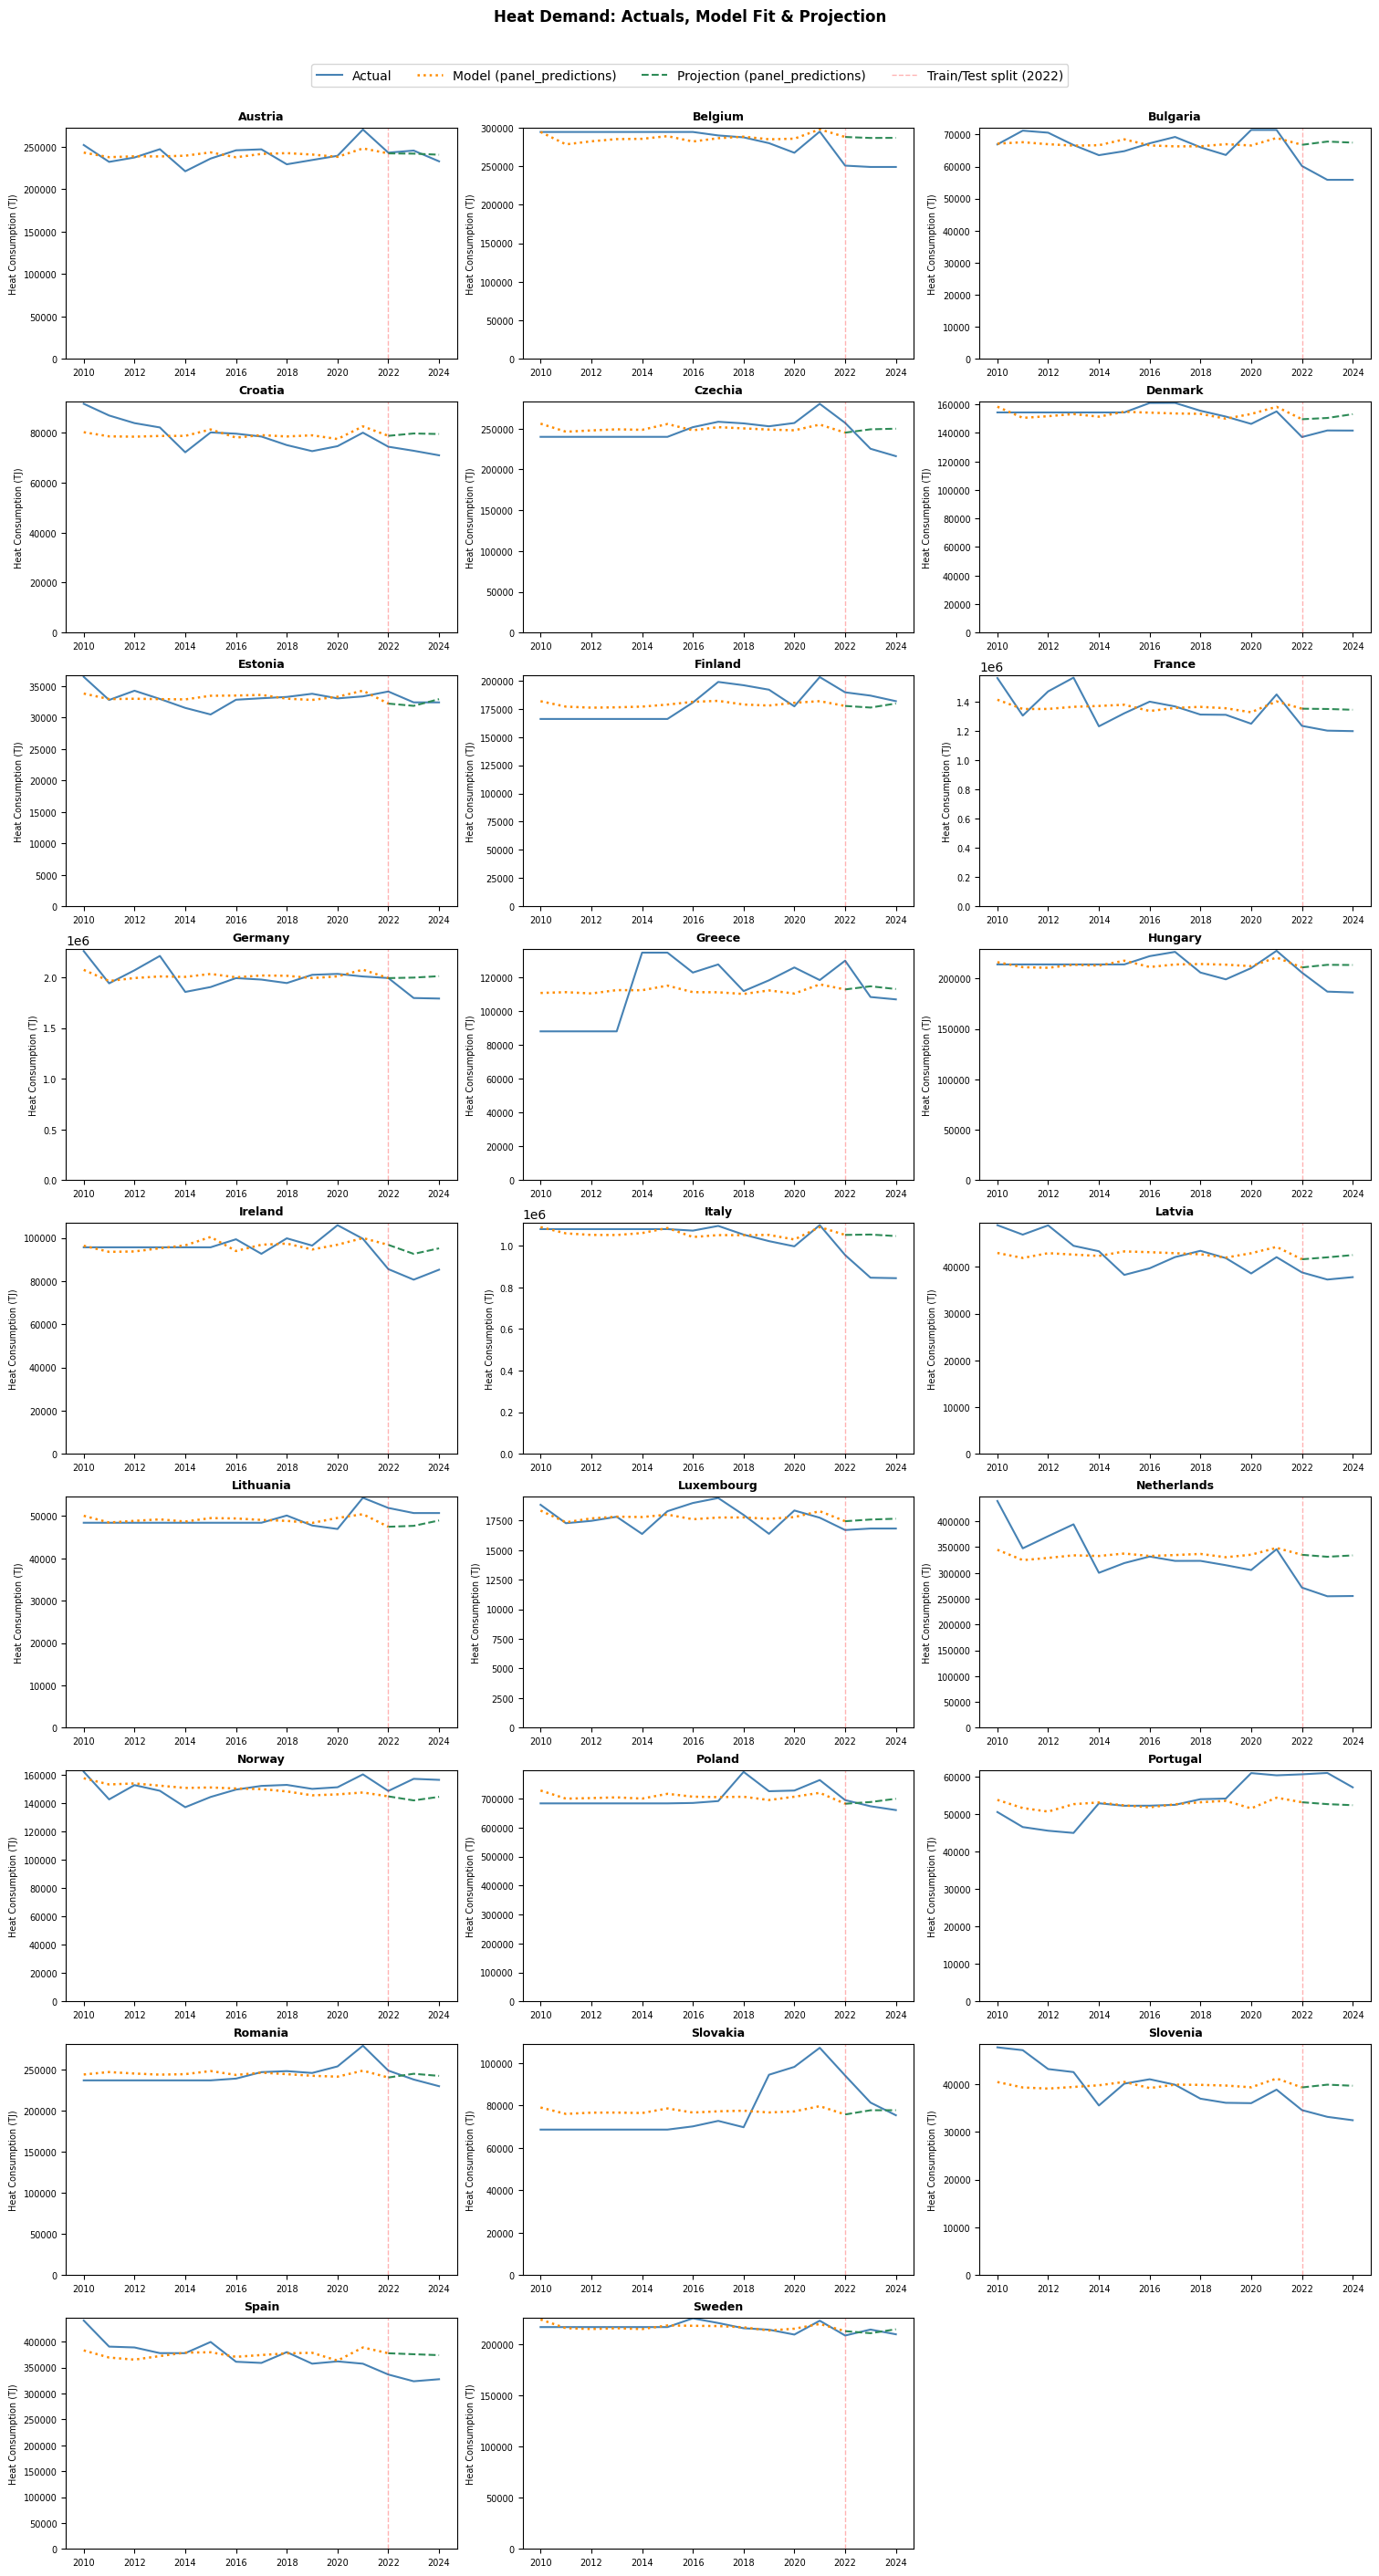

In [135]:
# predictions for historical data (training set)
hist = predict_logaritmic(m_panelOLS, hist, X_train, LN=True)

# Raw model projection for test set
#proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)
X_test = predict_logaritmic(m_panelOLS, X_test, X_test, LN=True)

# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=X_test,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=TRAIN_TEST_YEAR
)

The Model uses ln of input variables (population, gdp_per_capita, HDD) to calculate ln_total_heat

### Training on all historical data

In [136]:
X = hist[FEATURES]
Y = hist[TARGET_ln]

#X = sm.add_constant(X)

m_panelOLS = PanelOLS(Y, X,
                      entity_effects=True,
                      ).fit(
                        #cov_type="clustered",
                        #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.0915
Estimator:,PanelOLS,R-squared (Between):,-13.689
No. Observations:,390,R-squared (Within):,0.0915
Date:,"Tue, Jul 07 2026",R-squared (Overall):,-13.688
Time:,17:35:02,Log-likelihood,442.78
Cov. Estimator:,Unadjusted,,
,,F-statistic:,9.0594
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(4,360)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,9.0594


In [137]:
# predictions for historical data
hist = predict_logaritmic(m_panelOLS, hist, X, LN=True)

# Raw model projection 2025–2060
X_proj = proj[FEATURES]
#X_proj = sm.add_constant(X_proj)
proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)

In [138]:
# ── DIAGNOSTIC: Does RENOVATION_RATE correctly affect Total_Heat_TJ in 2060? ──
#
# This cell checks three things WITHOUT changing any existing code:
#   1. Sign and magnitude of the ln_thermal_index coefficient
#   2. How much thermal_index actually varies in historical data (why coefficient may be weak)
#   3. Whether varying RENOVATION_RATE produces the expected direction in 2060 predictions

print('=' * 70)
print('1. MODEL COEFFICIENTS')
print('=' * 70)
print(m_panelOLS.params.to_string())
coef_thermal = m_panelOLS.params['ln_thermal_index']
print(f'\nln_thermal_index coefficient: {coef_thermal:.4f}')
if coef_thermal > 0:
    print('  Sign is POSITIVE → higher thermal_index predicts more heat demand (correct direction)')
    print('  → Lower thermal_index (from renovation) should reduce predicted heat demand')
else:
    print('  !! Sign is NEGATIVE → model predicts LESS heat demand when insulation is WORSE !!')
    print('  !! This is a WRONG sign — renovation would INCREASE predicted heat demand !!')
print()

print('=' * 70)
print('2. WITHIN-COUNTRY VARIATION OF thermal_index IN HISTORICAL DATA (2010–2024)')
print('   (PanelOLS with entity_effects only uses within-country variation)')
print('=' * 70)
ti_hist = hist['thermal_index'].reset_index()
variation = ti_hist.groupby('country')['thermal_index'].agg(['min', 'max', 'std'])
variation['range'] = variation['max'] - variation['min']
variation['range_%'] = (variation['range'] / variation['max'] * 100).round(2)
print(variation[['min', 'max', 'range', 'range_%']].round(2).sort_values('range_%').to_string())
print()
avg_range_pct = variation['range_%'].mean()
print(f'Average within-country range: {avg_range_pct:.2f}% of max')
if avg_range_pct < 3:
    print('  !! Historical thermal_index barely varies within countries — coefficient is poorly identified !!')
    print('  !! The model cannot learn a reliable beta for ln_thermal_index from this data !!')
print()

print('=' * 70)
print('3. SCENARIO COMPARISON: thermal_index and predicted heat demand in 2060')
print('   Using the CURRENT model (same coefficients/entity-effects), only varying RENOVATION_RATE')
print('=' * 70)

# Entity effects from the trained model
_entity_effects = m_panelOLS.estimated_effects.groupby('country')['estimated_effects'].mean()

# 2060 features from proj (GDP growth, HDD) — these don't change across scenarios
_proj_2060 = proj.xs(2060, level='year')[['gdp_growth_rate_Percent', 'ln_hdd']].copy()

# Helper: build thermal_index for a single year given a renovation rate
def thermal_index_for_year(target_year, renovation_rate):
    rows = []
    for country, r in bso.iterrows():
        At = r['gesamtfläche_m2']
        A2020 = {p: r[c]*At for p, c in PERIOD_COLS.items()}
        annual_new = A2020['2011-now'] / NEWEST_SPAN
        annual_renovation = At * renovation_rate
        area = {p: A2020[p] for p in OLD_PERIODS}
        area['2011-now']  = annual_new * min(max(0, target_year - 2010), NEWEST_SPAN)
        area['post-2020'] = annual_new * max(0, target_year - 2020)
        cumulative = annual_renovation * max(0, target_year - 2010)
        remaining = cumulative
        for p in OLD_PERIODS:
            if remaining <= 0:
                break
            sub = min(area[p], remaining)
            area[p] -= sub
            remaining -= sub
        tot = sum(area.values())
        intens = {**INTENSITY, 'post-2020': INTENSITY_POST2020}
        ti = sum(area[p]*intens[p] for p in area) / tot
        rows.append({'country': country, 'thermal_index': ti, 'total_floor_m2': tot})
    return pd.DataFrame(rows).set_index('country')

test_rates = [0.001, 0.005, 0.010, 0.020]
scenario_results = []
baseline_ti = None
baseline_heat = None

for rate in test_rates:
    fp_2060 = thermal_index_for_year(2060, rate)
    fp_2060['ln_thermal_index'] = np.log1p(fp_2060['thermal_index'])
    fp_2060['ln_total_floor']   = np.log1p(fp_2060['total_floor_m2'])

    X_scenario = _proj_2060.copy()
    X_scenario['ln_total_floor']   = fp_2060['ln_total_floor']
    X_scenario['ln_thermal_index'] = fp_2060['ln_thermal_index']
    X_scenario = X_scenario[FEATURES]  # keep column order consistent

    # Manual prediction: X @ beta (no entity effects in predict output)
    beta = m_panelOLS.params
    xbeta = X_scenario.dot(beta)
    ln_pred = xbeta + _proj_2060.index.map(_entity_effects)
    heat_pred = np.expm1(ln_pred)

    avg_ti = fp_2060['thermal_index'].mean()
    total_heat = heat_pred.sum()

    if baseline_ti is None:
        baseline_ti   = avg_ti
        baseline_heat = total_heat

    scenario_results.append({
        'renovation_rate': rate,
        'avg_thermal_index_2060': avg_ti,
        'ti_vs_baseline_%': (avg_ti - baseline_ti) / baseline_ti * 100,
        'total_EU_heat_2060_TJ': total_heat,
        'heat_vs_baseline_%': (total_heat - baseline_heat) / baseline_heat * 100,
    })

results_df = pd.DataFrame(scenario_results)
print(results_df.round(2).to_string(index=False))
print()
print('EXPECTED: As renovation_rate increases → avg_thermal_index_2060 decreases → total_EU_heat_2060_TJ decreases')
print('If heat_vs_baseline_% does NOT decrease with higher renovation rate → model is broken')


1. MODEL COEFFICIENTS
gdp_growth_rate_Percent    0.003836
ln_hdd                     0.130272
ln_total_floor             2.100116
ln_thermal_index           3.041895

ln_thermal_index coefficient: 3.0419
  Sign is POSITIVE → higher thermal_index predicts more heat demand (correct direction)
  → Lower thermal_index (from renovation) should reduce predicted heat demand

2. WITHIN-COUNTRY VARIATION OF thermal_index IN HISTORICAL DATA (2010–2024)
   (PanelOLS with entity_effects only uses within-country variation)
                min     max  range  range_%
country                                    
Austria      180.76  185.75   4.99     2.69
Finland      164.75  170.52   5.77     3.38
Slovakia     170.10  176.68   6.58     3.72
Belgium      196.38  205.13   8.75     4.27
Germany      180.10  189.53   9.43     4.97
Greece       157.01  167.07  10.05     6.02
Hungary      165.05  176.42  11.37     6.45
Netherlands  168.73  180.76  12.03     6.65
Latvia       159.72  171.27  11.55     6.74


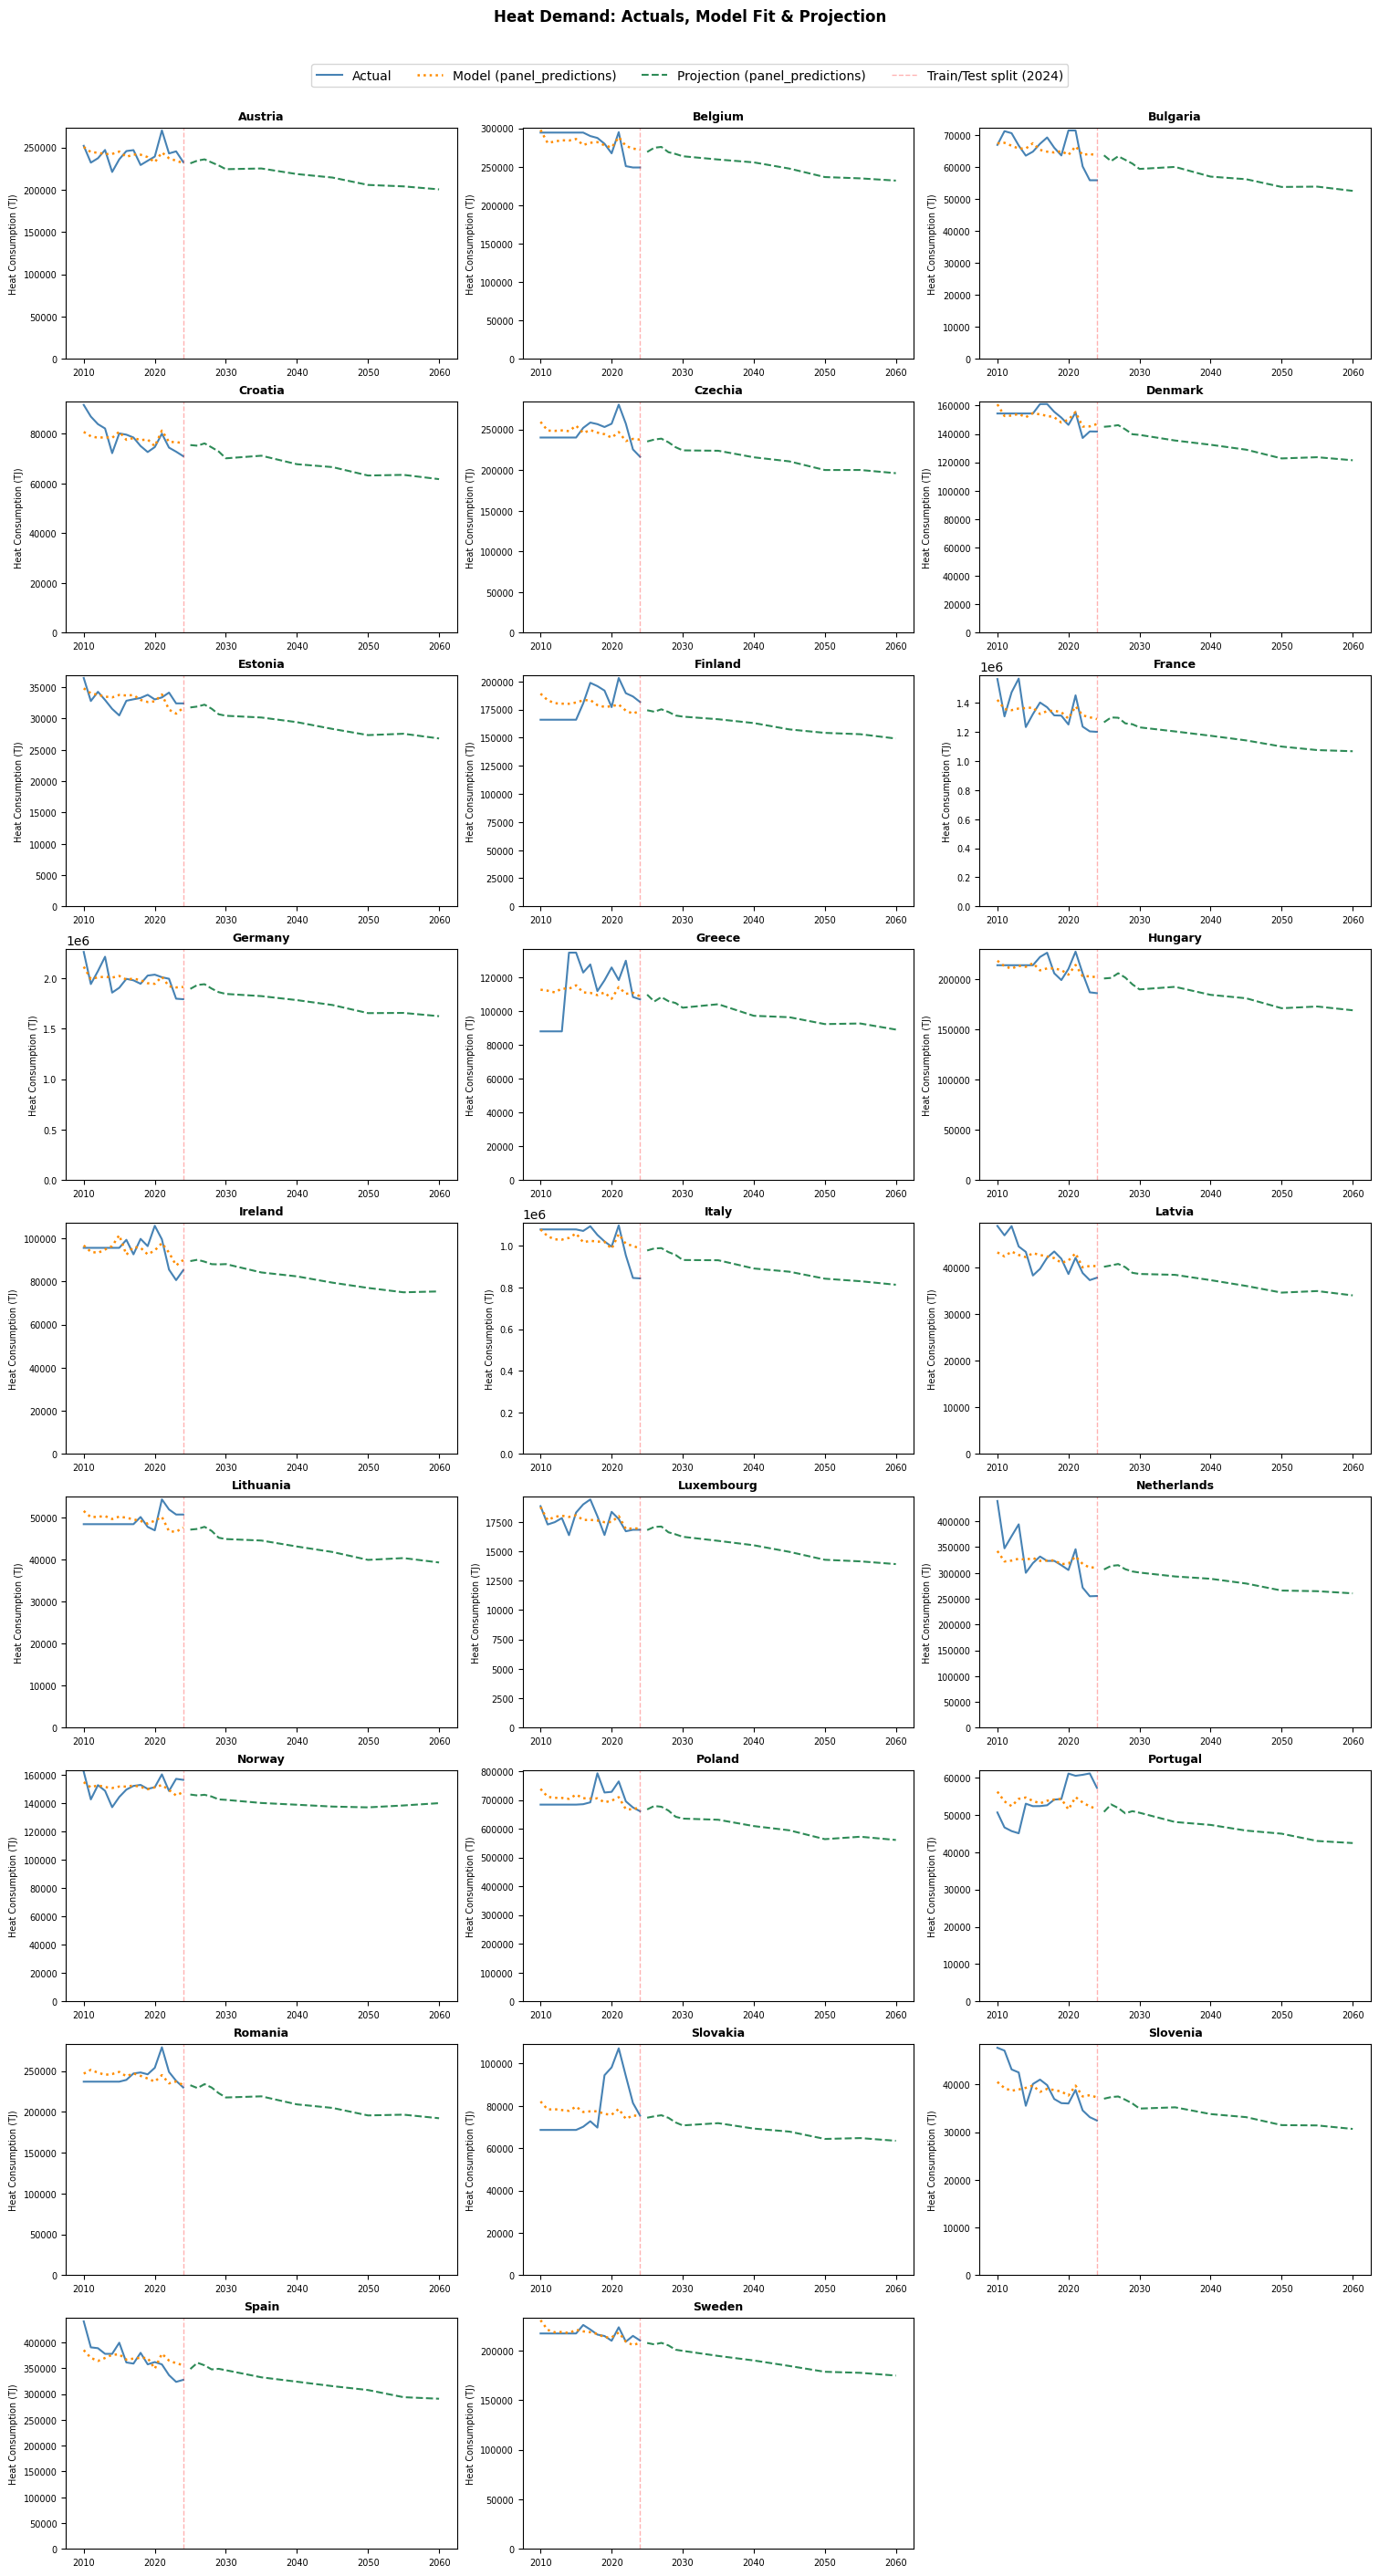

In [139]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=hist.index.get_level_values('year').max()
)

# Heat Pump Share Projection

In [140]:
hp_shares_hist = nrg_d_hhq_heating[nrg_d_hhq_heating.carrier == "Ambient heat (heat pumps)"]
hp_shares_hist = hp_shares_hist[["country", "year", "share_pu"]]

# filling the last value for Bulgaria
hp_shares_hist.loc[
    (hp_shares_hist["country"] == "Bulgaria") & 
    (hp_shares_hist["year"] == 2024), 
    "share_pu"
] = 0

hp_shares_hist[hp_shares_hist.country == "Lithuania"]

,country,year,share_pu
223,Lithuania,2010,NaN
224,Lithuania,2011,NaN
225,Lithuania,2012,NaN
226,Lithuania,2013,NaN
227,Lithuania,2014,NaN
228,Lithuania,2015,NaN
229,Lithuania,2016,NaN
230,Lithuania,2017,0.000000
231,Lithuania,2018,0.018591
232,Lithuania,2019,0.020451


In [141]:
# year when max share is reached, and what fraction of max is the target
SCENARIOS = {
    "KKO": {"target_year": 2050, "target_fraction": 0.9},
    "KVE": {"target_year": 2055, "target_fraction": 0.9},
    "VWE": {"target_year": 2060, "target_fraction": 0.9},
    "VNI": {"target_year": 2060, "target_fraction": 0.75},
}

In [142]:
# Building share projections per scenario --> hp_shares_proj
# The development of heat pump shares follows a logistic S-curve (technology diffusion)
PROJ_YEARS = list(range(2025, 2061))

def project_hp_share_scurve(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    # sigmoid parameters: inflection at midpoint, k chosen so curve spans ~5%–95% over the period
    duration  = target_year - 2024
    t_mid     = 2024 + duration / 2
    k         = 6 / duration

    # normalize so progress = 0 at t=2024 and progress = 1 at t=target_year
    sig_start = 1 / (1 + np.exp(-k * (2024        - t_mid)))
    sig_end   = 1 / (1 + np.exp(-k * (target_year - t_mid)))

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            sig_t    = 1 / (1 + np.exp(-k * (year - t_mid)))
            progress = (sig_t - sig_start) / (sig_end - sig_start)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share_scurve(country, scenario))

hp_shares_proj = pd.DataFrame(all_rows)
#print(hp_shares_proj.head(20).to_string())
#print(f"\nShape: {hp_shares_proj.shape}")
hp_shares_proj[hp_shares_proj.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.085123
541,Lithuania,2026,KKO,0.086287
542,Lithuania,2027,KKO,0.087705
543,Lithuania,2028,KKO,0.089417
544,Lithuania,2029,KKO,0.091465
...,...,...,...,...
3379,Lithuania,2056,VNI,0.129857
3380,Lithuania,2057,VNI,0.130520
3381,Lithuania,2058,VNI,0.131095
3382,Lithuania,2059,VNI,0.131593


In [143]:
# Building share projections per scenario --> hp_shares_proj_linear  (kept for reference)
# The development of heat pump shares are linear
def project_hp_share(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            # linear interpolation between 2024 and target_year
            progress = (year - 2024) / (target_year - 2024)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share(country, scenario))

hp_shares_proj_linear = pd.DataFrame(all_rows)
#print(hp_shares_proj_linear.head(20).to_string())
#print(f"\nShape: {hp_shares_proj_linear.shape}")
hp_shares_proj_linear[hp_shares_proj_linear.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.087028
541,Lithuania,2026,KKO,0.089884
542,Lithuania,2027,KKO,0.092740
543,Lithuania,2028,KKO,0.095596
544,Lithuania,2029,KKO,0.098452
...,...,...,...,...
3379,Lithuania,2056,VNI,0.126706
3380,Lithuania,2057,VNI,0.128035
3381,Lithuania,2058,VNI,0.129364
3382,Lithuania,2059,VNI,0.130693


In [144]:
hp_shares_proj

,country,year,scenario,share_pu
0,Austria,2025,KKO,0.072136
1,Austria,2026,KKO,0.077281
2,Austria,2027,KKO,0.083545
3,Austria,2028,KKO,0.091111
4,Austria,2029,KKO,0.100159
...,...,...,...,...
3739,Sweden,2056,VNI,0.023349
3740,Sweden,2057,VNI,0.023688
3741,Sweden,2058,VNI,0.023982
3742,Sweden,2059,VNI,0.024236


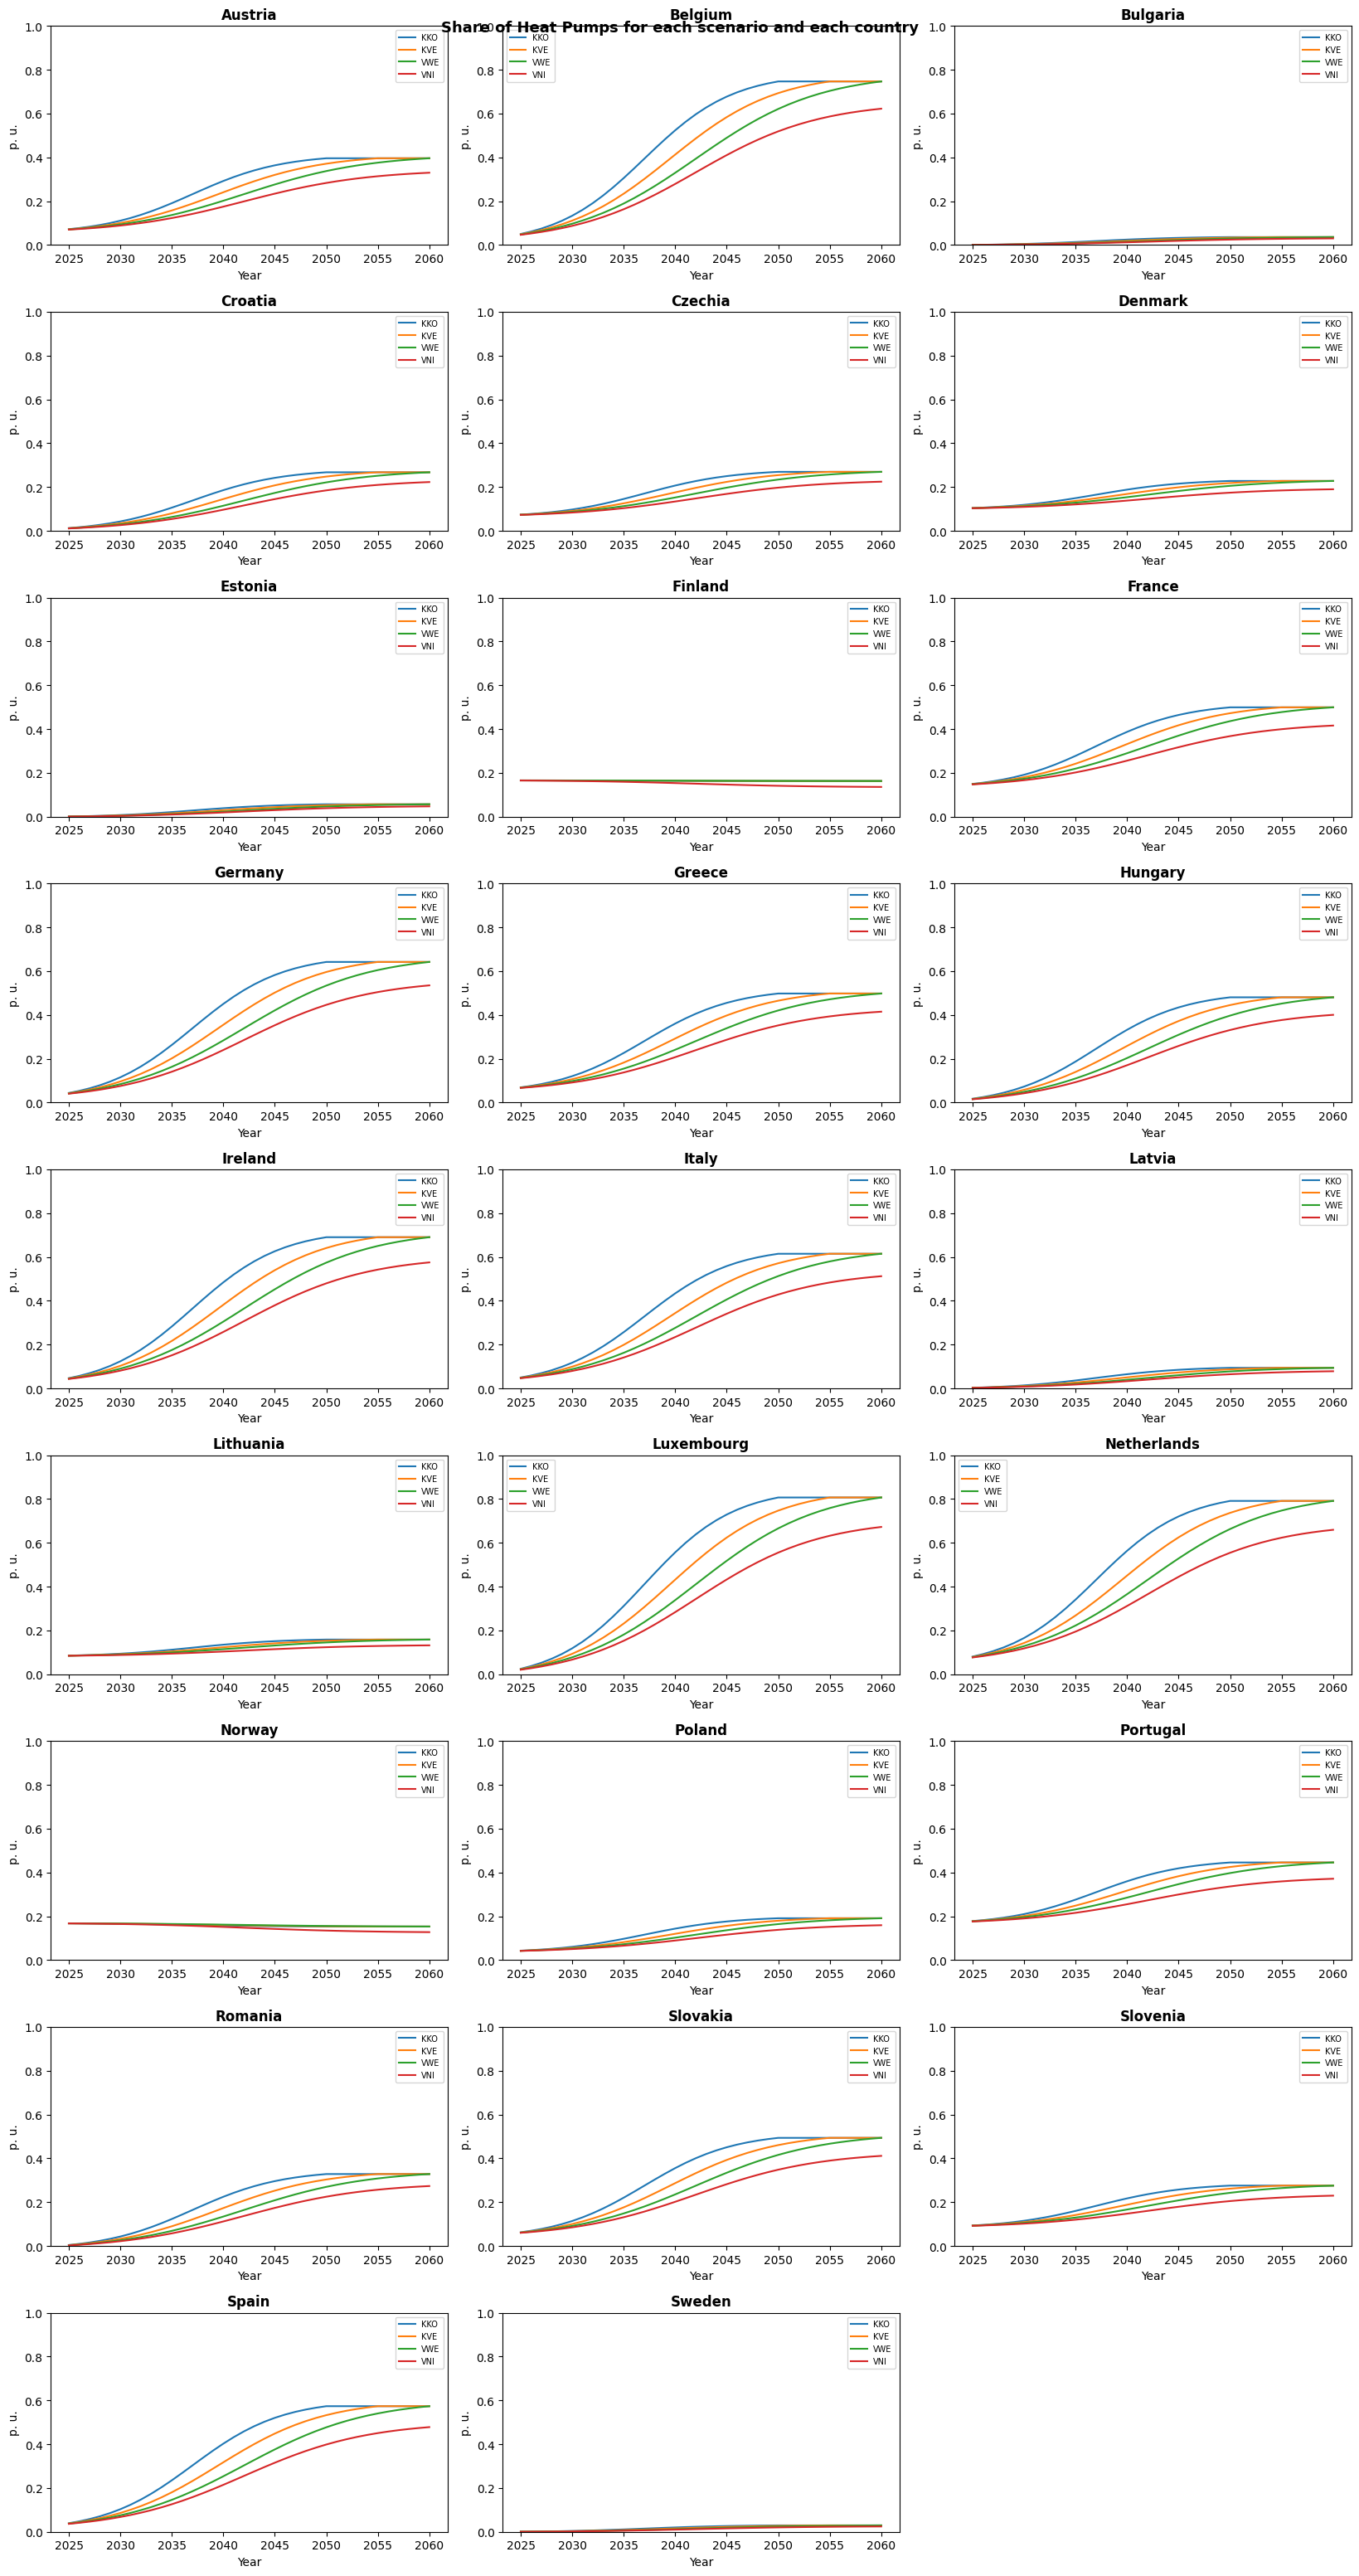

In [145]:
import matplotlib.pyplot as plt
import math

PROJECTION = hp_shares_proj # or hp_shares_proj_linear or hp_shares_proj

ALL_COUNTRIES = sorted(ALL_COUNTRIES)

n_cols = 3
n_rows = math.ceil(len(ALL_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, ALL_COUNTRIES):
    for scenario in SCENARIOS:
        d = PROJECTION[
            (PROJECTION["country"]  == country) &
            (PROJECTION["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["share_pu"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("p. u.")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.0)

# hide unused subplots
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Share of Heat Pumps for each scenario and each country",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()

# Calculation of HP Electricity Demand

In [146]:
proj

,,gdp_growth_rate_Percent,ln_hdd,ln_total_floor,ln_thermal_index,total_floor_m2,thermal_index,panel_predictions
country,year,,,,,,,
Austria,2025,-0.036296,8.125675,19.985640,5.200618,4.782481e+08,180.384326,231239.341183
Belgium,2025,1.156512,7.648291,20.360879,5.281868,6.960130e+08,195.736952,269221.863537
Bulgaria,2025,2.927476,7.767877,19.604039,5.121548,3.265323e+08,166.594636,63648.729780
Croatia,2025,3.896182,7.495500,19.053950,5.000038,1.883760e+08,147.418833,75405.766527
Czechia,2025,2.120203,7.954813,19.799036,5.091112,3.968369e+08,161.570568,235150.052194
...,...,...,...,...,...,...,...,...
Romania,2060,1.007720,7.841816,20.190893,4.778822,5.872101e+08,117.964093,192212.977320
Slovakia,2060,0.888031,7.957286,18.996517,5.041417,1.778617e+08,153.689041,63481.750651
Slovenia,2060,1.617258,7.715048,18.197894,4.933376,8.002858e+07,137.847411,30681.200803


## COP Calculation

In [147]:
# ── COP mode ─────────────────────────────────────────────────────────────────
# Formula (dynamic):  COP = COP_base[country] × (THERMAL_REF / thermal_index) ^ COP_ALPHA
#   poorly insulated building → high thermal_index → high supply temp → low COP
#   well  insulated building  → low  thermal_index → low  supply temp → high COP

USE_DYNAMIC_COP = True   # False → constant per-country COP (old behavior)
                          # True  → COP coupled to thermal_index (time-varying)

COP_ALPHA   = 0.3    # exponent controlling coupling strength; 0 = no effect, higher = stronger
                     # Germany 2025 (TI≈180, THERMAL_REF=100): factor=(100/180)=0.556
                     #   α=0.0 → 0.556^0.0=1.000 → COP=4.00  (= constant mode)
                     #   α=0.1 → 0.556^0.1=0.941 → COP=3.76
                     #   α=0.3 → 0.556^0.3=0.834 → COP=3.34  ← chosen (matches field data)
                     #   α=0.5 → 0.556^0.5=0.745 → COP=2.98
                     #   α=1.0 → 0.556^1.0=0.556 → COP=2.22  (too strong)

THERMAL_REF = 150    # kWh/m²a at which COP = COP_base (anchor point of the formula)
COP_MAX     = 6.5    # upper cap — prevents unrealistic values for near-zero energy stock

# country base COP — captures climate-zone / heat source temperature differences
# (Rivière et al. 2009): Nordic=3.3, West/Central=4.0, Eastern=3.5, Southern=4.3
COP_MAP = {
    "Austria": 4.0, "Belgium": 4.0, "Bulgaria": 3.5, "Croatia": 4.3,
    "Czechia": 3.5, "Denmark": 3.3, "Estonia": 3.3, "Finland": 3.3,
    "France": 4.0,  "Germany": 4.0, "Greece": 4.3,  "Hungary": 3.5,
    "Ireland": 4.0, "Italy": 4.0,   "Latvia": 3.3,  "Lithuania": 3.3,
    "Luxembourg": 4.0, "Netherlands": 4.0, "Norway": 3.3, "Poland": 3.5,
    "Portugal": 4.3,   "Romania": 3.5,    "Slovakia": 3.5, "Slovenia": 4.3,
    "Spain": 4.3,      "Sweden": 3.3,
}
# ─────────────────────────────────────────────────────────────────────────────

cop_df = floor_panel[["thermal_index"]].copy().reset_index()
cop_df["COP_base"] = cop_df["country"].map(COP_MAP)   # climate-zone anchor, preserved in both modes

if USE_DYNAMIC_COP:
    # COP_ALPHA enters here as the exponent — shifts all countries proportionally
    # while keeping their relative differences via COP_base
    cop_df["COP"] = (
        cop_df["COP_base"] * (THERMAL_REF / cop_df["thermal_index"]) ** COP_ALPHA
    ).clip(upper=COP_MAX)
else:
    cop_df["COP"] = cop_df["COP_base"]   # identical to old constant behavior

cop_df = cop_df.set_index(["country", "year"])

# preview
cop_df.loc[
    cop_df.index.get_level_values("country").isin(["Germany", "Sweden", "Spain"]) &
    cop_df.index.get_level_values("year").isin([2020, 2030, 2040, 2050, 2060])
][["thermal_index", "COP_base", "COP"]]

thermal_index  COP_base       COP
country year                                   
Germany 2020     182.891424       4.0  3.769028
        2030     176.051854       4.0  3.812371
        2040     169.636869       4.0  3.855061
        2050     163.608122       4.0  3.897139
        2060     157.931751       4.0  3.938642
Spain   2020     150.831822       4.3  4.292872
        2030     141.440016       4.3  4.376472
        2040     133.170142       4.3  4.456293
        2050     125.832494       4.3  4.532711
        2060     119.277854       4.3  4.606042
Sweden  2020     157.519163       3.3  3.251931
        2030     144.562411       3.3  3.336758
        2040     133.736923       3.3  3.415591
        2050     124.556804       3.3  3.489242
        2060     116.673426       3.3  3.558359

In [148]:
PROJ_YEARS = [2025, 
              2026, 2027, 2028, 2029, 
              2030, 2035, 2040, 2045, 2050, 2055, 2060]

# COP by country group (from Rivière et al. 2009)
#Southern Europe  & ES, PT, IT, GR, HR, SI & 4.3 
#Western/Central  & FR, DE, AT, BE, NL, LU, IE & 4.0
#Eastern Europe   & PL, CZ, SK, HU, RO, BG & 3.5 
#Nordic/Baltic    & SE, FI, NO, DK, EE, LV, LT & 3.3 

# service sector multiplier (HP demand in services on top of residential)
#SERVICE_MULTIPLIER = 1.25
SERVICE_MULTIPLIER = 1

# merge projection shares with total heat demand from ML model
proj = proj.reset_index()
proj_heat = proj[["country", "year", "panel_predictions"]].copy()

hp_demand_proj = hp_shares_proj.merge(proj_heat,
                                       on=["country", "year"],
                                       how="left")

#hp_demand_proj["COP"] = hp_demand_proj["country"].map(COP_MAP)
hp_demand_proj = hp_demand_proj.merge(
    cop_df[["COP"]].reset_index(), on=["country", "year"], how="left"
)

# formula: Demand_HP (TWh) = Heat(TJ) * (1/3600) * share_HP / (COP-1) * 1.25
hp_demand_proj["Demand_HP_TWh"] = (
    hp_demand_proj["panel_predictions"]
    * (1 / 3600)
    * hp_demand_proj["share_pu"]
    #/ (hp_demand_proj["COP"] - 1)
    / (hp_demand_proj["COP"])
    * SERVICE_MULTIPLIER
)

#print(hp_demand_proj.head(20).to_string())
#print(f"\nShape: {hp_demand_proj.shape}")
hp_demand_proj = hp_demand_proj[hp_demand_proj.year.isin(PROJ_YEARS)]
hp_demand_proj = hp_demand_proj.reset_index(drop=True)
hp_demand_proj[hp_demand_proj.country=="Germany"]

,country,year,scenario,share_pu,panel_predictions,COP,Demand_HP_TWh
108,Germany,2025,KKO,0.043720,1.892264e+06,3.790784,6.062258
109,Germany,2026,KKO,0.053225,1.930904e+06,3.795115,7.522330
110,Germany,2027,KKO,0.064797,1.938335e+06,3.799439,9.182538
111,Germany,2028,KKO,0.078772,1.895149e+06,3.803756,10.901912
112,Germany,2029,KKO,0.095488,1.859625e+06,3.808067,12.952934
113,Germany,2030,KKO,0.115252,1.842168e+06,3.812371,15.469629
114,Germany,2035,KKO,0.263078,1.820556e+06,3.833795,34.702203
115,Germany,2040,KKO,0.450462,1.780874e+06,3.855061,57.803999
116,Germany,2045,KKO,0.582497,1.732361e+06,3.876174,72.314694
117,Germany,2050,KKO,0.642021,1.652276e+06,3.897139,75.610749


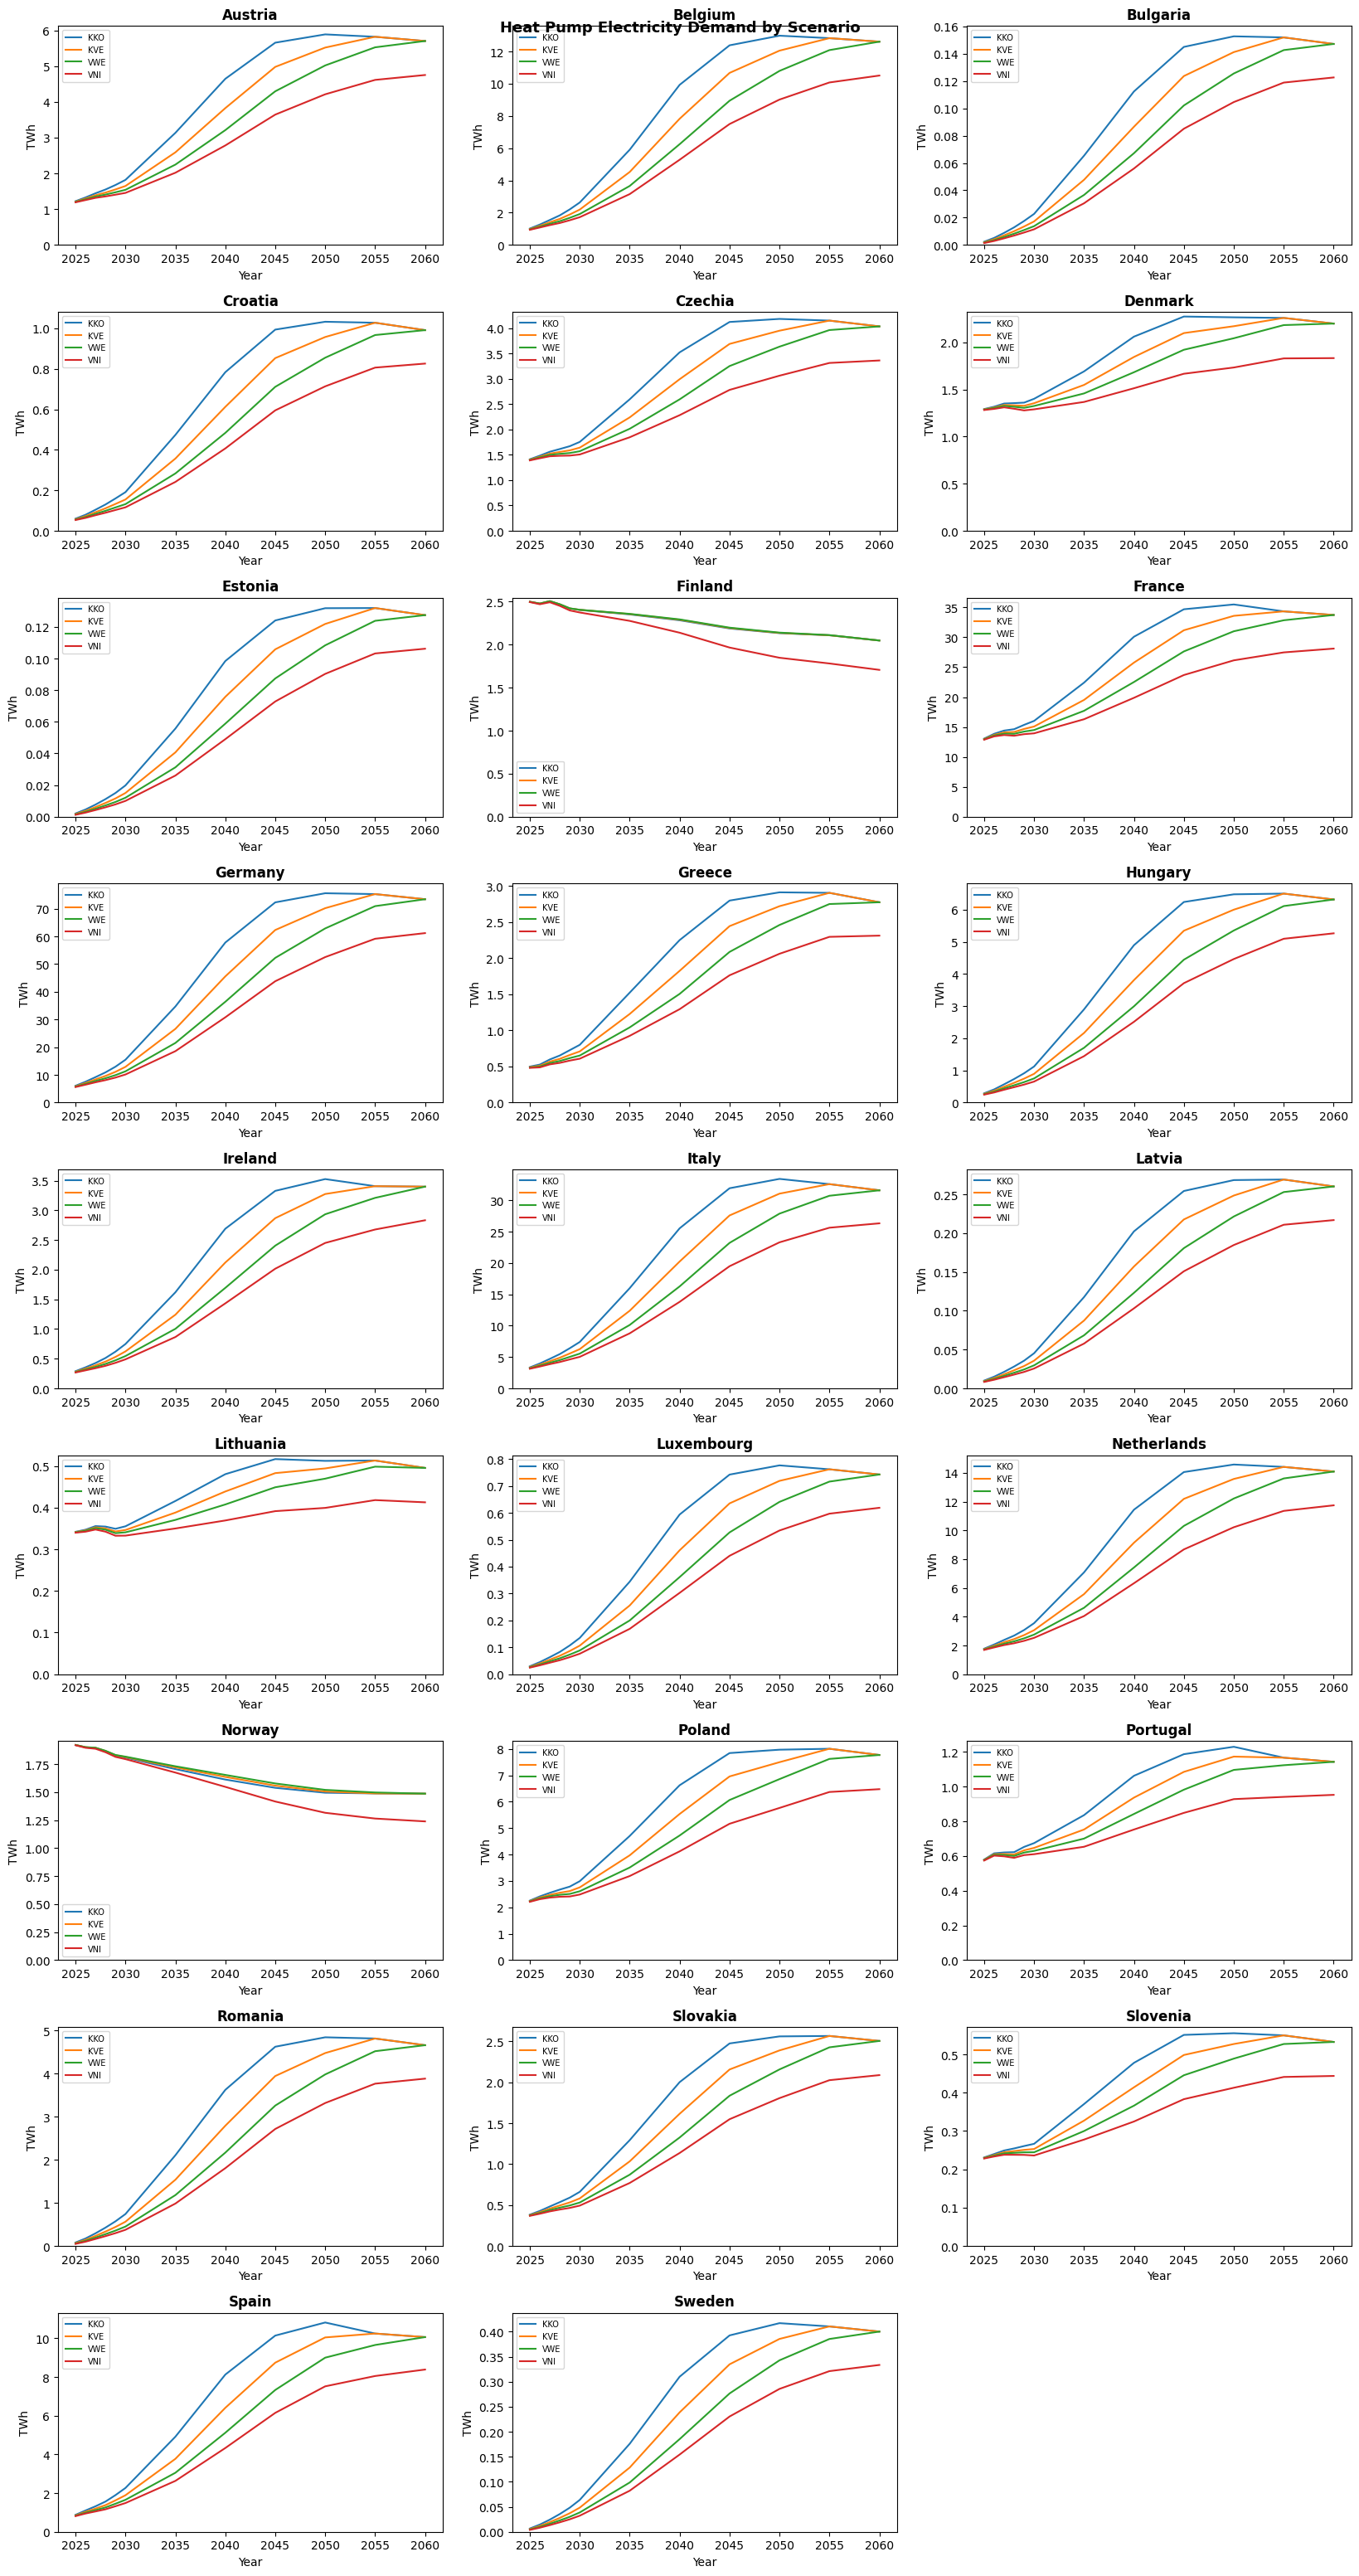

In [149]:
import matplotlib.pyplot as plt
import math

CHECK_COUNTRIES = ALL_COUNTRIES   # or any list of countries
#CHECK_COUNTRIES = ["Bulgaria"]

CHECK_COUNTRIES = sorted(CHECK_COUNTRIES)

n_cols = 3
n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, CHECK_COUNTRIES):
    for scenario in SCENARIOS:
        d = hp_demand_proj[
            (hp_demand_proj["country"]  == country) &
            (hp_demand_proj["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["Demand_HP_TWh"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")
    ax.legend(fontsize=7)
    ax.set_ylim(0, )

# hide unused subplots
for ax in axes[len(CHECK_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Heat Pump Electricity Demand by Scenario",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()


In [150]:
hp_demand_proj[hp_demand_proj["country"] == "Germany"]

,country,year,scenario,share_pu,panel_predictions,COP,Demand_HP_TWh
108,Germany,2025,KKO,0.043720,1.892264e+06,3.790784,6.062258
109,Germany,2026,KKO,0.053225,1.930904e+06,3.795115,7.522330
110,Germany,2027,KKO,0.064797,1.938335e+06,3.799439,9.182538
111,Germany,2028,KKO,0.078772,1.895149e+06,3.803756,10.901912
112,Germany,2029,KKO,0.095488,1.859625e+06,3.808067,12.952934
113,Germany,2030,KKO,0.115252,1.842168e+06,3.812371,15.469629
114,Germany,2035,KKO,0.263078,1.820556e+06,3.833795,34.702203
115,Germany,2040,KKO,0.450462,1.780874e+06,3.855061,57.803999
116,Germany,2045,KKO,0.582497,1.732361e+06,3.876174,72.314694
117,Germany,2050,KKO,0.642021,1.652276e+06,3.897139,75.610749
